# Fase 2 — Aumentación de Datos
**Entrada:** `arxiv_cs_top10_cleaned.parquet`  
**Salida:** `arxiv_cs_top10_augmented.parquet`

## Estrategia
1. **Back-translation EN→ES→EN** con MarianMT (`Helsinki-NLP/opus-mt-en-es` + `opus-mt-es-en`)  
2. **Paráfrasis con T5** (`t5-base`)

**Objetivo:** igualar todas las clases al volumen de la clase mayoritaria.  

---
## Imports y configuración global

In [23]:
import pandas as pd
import numpy as np
import torch
import random
import os
import time
import warnings
from pathlib import Path
from tqdm.auto import tqdm
from transformers import MarianMTModel, MarianTokenizer, T5ForConditionalGeneration, T5Tokenizer

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

#  Rutas 
DATA_DIR      = Path(r'C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset')  
INPUT_FILE    = DATA_DIR / 'arxiv_cs_top10_limpieza_baseline.parquet'
OUTPUT_FILE   = DATA_DIR / 'arxiv_test_aug.parquet'
OUTPUT_TRAIN  = DATA_DIR / 'arxiv_train_orig.parquet'
OUTPUT_VAL    = DATA_DIR / 'arxiv_val.parquet'
OUTPUT_TEST   = DATA_DIR / 'arxiv_test.parquet'

#  Hiperparámetros de aumentación 
BATCH_SIZE_BT  = 16    # back-translation: batch size (ajusta según VRAM)
BATCH_SIZE_T5  = 8     # T5 paráfrasis: batch size
MAX_INPUT_LEN  = 256   # tokens de entrada (abstracts arXiv: ~150 palabras)
MAX_OUTPUT_LEN = 280   # tokens de salida generada
NUM_BEAMS      = 4     # beam search
TEMP_T5        = 1.0   # temperatura T5 (1.0 = estocástico moderado)
AUG_CEILING    = 50_000   # techo del balanceo

print(r'\nConfiguracion cargada correctamente.')

Dispositivo: cuda
GPU: NVIDIA GeForce RTX 5090
VRAM disponible: 34.2 GB
\nConfiguracion cargada correctamente.


---
## Hacer Split para que se va a ocupar para todos los experimentos + el dataset aumentado.

```mermaid
graph TD
    A[arxiv_cs_top10_limpieza_baseline.parquet] --> B[Split 80/10/10 estratificado<br>]
    
    B --> C(arxiv_train_orig)
    B --> D(arxiv_val)
    B --> E(arxiv_test)
    
    C -->|Aumentación| F[arxiv_train_aug]
    
    
    
    F --> G[Entrenar BiLSTM / SciBERT]
    
    D -.->|Validar durante entrenamiento| G
    E -.->|Evaluar mejor modelo| G
    
    G --> I[Evaluar sobre UAM-A 733 docs<br><i>evaluación de transferencia</i>]

In [5]:
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_parquet(INPUT_FILE)

# Paso 1: separar test primero, sobre el corpus completo
df_trainval, df_test = train_test_split(
    df,
    test_size=0.10,
    random_state=42,
    stratify=df['cs_primary']
)

# Paso 2: separar val del restante 
# 0.1111 del 90% restante ≈ 10% del total original
df_train, df_val = train_test_split(
    df_trainval,
    test_size=0.1111,
    random_state=42,
    stratify=df_trainval['cs_primary']
)

#  Verificación 
print(f'Total    : {len(df):,}')
print(f'Train    : {len(df_train):,} ({len(df_train)/len(df)*100:.1f}%)')
print(f'Val      : {len(df_val):,} ({len(df_val)/len(df)*100:.1f}%)')
print(f'Test     : {len(df_test):,} ({len(df_test)/len(df)*100:.1f}%)')

# Verificar estratificación
print('\nDistribución por clase:')
for cls in sorted(df['cs_primary'].unique()):
    t = len(df_train[df_train['cs_primary']==cls])
    v = len(df_val[df_val['cs_primary']==cls])
    te = len(df_test[df_test['cs_primary']==cls])
    print(f'  {cls}: train={t:,}  val={v:,}  test={te:,}')

#  Paso 3: guardar los tres splits 
df_train.to_parquet(OUTPUT_TRAIN, index=False)
df_val.to_parquet(OUTPUT_VAL, index=False)
df_test.to_parquet(OUTPUT_TEST, index=False)

print('\nSplits guardados:')
print('  arxiv_train_orig.parquet  ← base para aumentación')
print('  arxiv_val.parquet         ← validación (solo originales, nunca aumentar)')
print('  arxiv_test.parquet        ← test interno (solo originales, nunca aumentar)')

Total    : 642,077
Train    : 513,667 (80.0%)
Val      : 64,202 (10.0%)
Test     : 64,208 (10.0%)

Distribución por clase:
  cs.AI: train=37,040  val=4,629  test=4,630
  cs.CL: train=64,532  val=8,066  test=8,067
  cs.CR: train=26,922  val=3,365  test=3,365
  cs.CV: train=126,937  val=15,866  test=15,867
  cs.DS: train=15,922  val=1,990  test=1,990
  cs.IT: train=37,587  val=4,698  test=4,698
  cs.LG: train=130,813  val=16,350  test=16,352
  cs.NA: train=21,420  val=2,677  test=2,678
  cs.RO: train=30,964  val=3,870  test=3,870
  cs.SY: train=21,530  val=2,691  test=2,691

Splits guardados:
  arxiv_train_orig.parquet  ← base para aumentación
  arxiv_val.parquet         ← validación (solo originales, nunca aumentar)
  arxiv_test.parquet        ← test interno (solo originales, nunca aumentar)


---
## 1. Carga y análisis de distribución de clases

In [6]:
df = pd.read_parquet(OUTPUT_TRAIN)
print(f'Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'Columnas: {df.columns.tolist()}')
print(f'\nMuestra de texto_limpio (200 chars):')
print(df['texto_limpio'].iloc[0][:200])

Dataset cargado: 513,667 filas × 4 columnas
Columnas: ['title', 'abstract', 'cs_primary', 'texto_limpio']

Muestra de texto_limpio (200 chars):
in the evolving field of explainable ai xai interpreting the decisions of deep neural networks dnns in computer vision tasks is an important process while pixelbased xai methods focus on identifying s


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

#  Distribución de clases 
dist = df['cs_primary'].value_counts().sort_values(ascending=False)
MAX_COUNT = dist.iloc[0]
CLASE_MAYORITARIA = dist.index[0]

print(f'Clase MAYORITARIA: {CLASE_MAYORITARIA} ({MAX_COUNT:,} ejemplos)\n')
print(f'{"Clase":<10} {"Actuales":>10} {"Necesarios":>12} {"% aumento":>10}')
print('-' * 46)

needed = {}
for cls, count in dist.items():
    n = MAX_COUNT - count
    needed[cls] = n
    pct = n / count * 100
    marker = '  ← mayoritaria' if n == 0 else ''
    print(f'{cls:<10} {count:>10,} {n:>12,} {pct:>9.1f}%{marker}')

total_nuevos = sum(needed.values())
print(f'\nTotal de ejemplos nuevos a generar: {total_nuevos:,}')
print(f'Corpus final esperado: {df.shape[0] + total_nuevos:,} filas')

Clase MAYORITARIA: cs.LG (130,813 ejemplos)

Clase        Actuales   Necesarios  % aumento
----------------------------------------------
cs.LG         130,813            0       0.0%  ← mayoritaria
cs.CV         126,937        3,876       3.1%
cs.CL          64,532       66,281     102.7%
cs.IT          37,587       93,226     248.0%
cs.AI          37,040       93,773     253.2%
cs.RO          30,964       99,849     322.5%
cs.CR          26,922      103,891     385.9%
cs.SY          21,530      109,283     507.6%
cs.NA          21,420      109,393     510.7%
cs.DS          15,922      114,891     721.6%

Total de ejemplos nuevos a generar: 794,463
Corpus final esperado: 1,308,130 filas


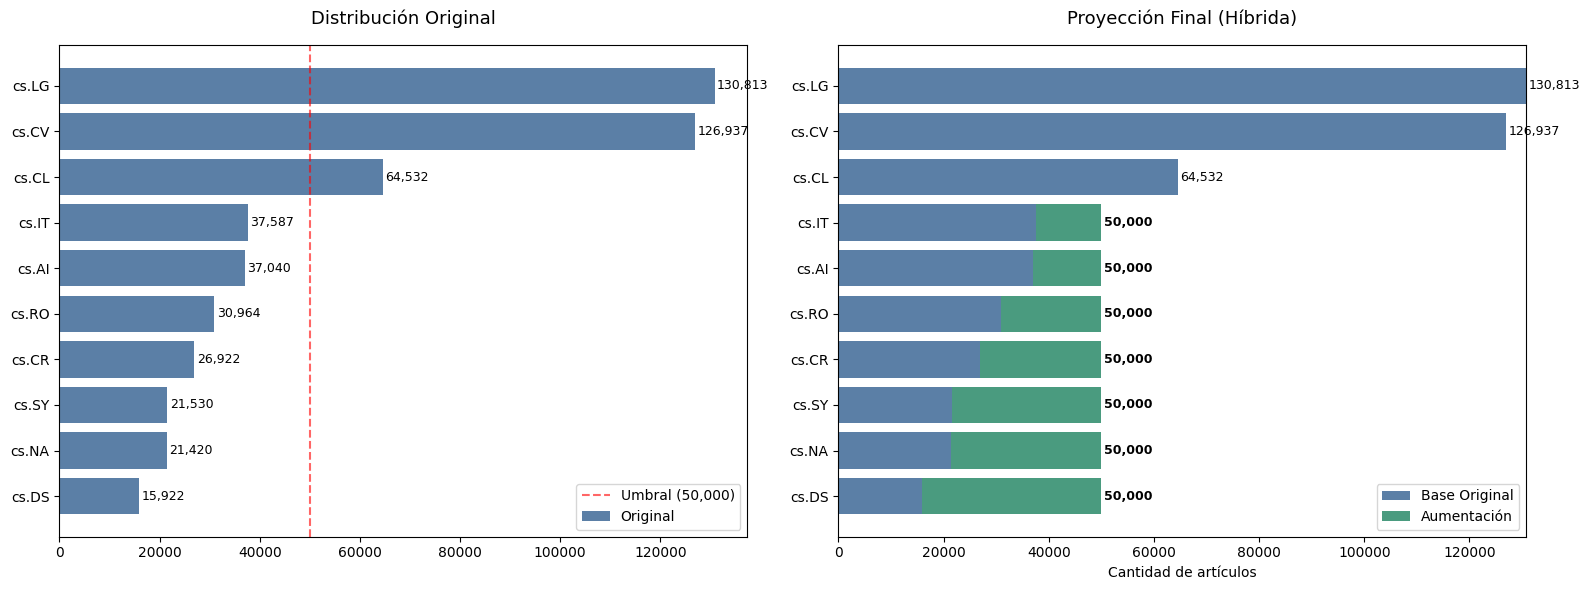

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración
TARGET_COUNT = 50000 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

clases = dist.index[::-1]
vals_orig = dist.values[::-1]

# --- GRÁFICO 1: ANTES ---
axes[0].barh(clases, vals_orig, color='#5b7fa6', label='Original')
axes[0].axvline(TARGET_COUNT, color='red', linestyle='--', alpha=0.6, label=f'Umbral ({TARGET_COUNT:,})')
axes[0].set_title('Distribución Original', fontsize=13, pad=15)
for i, v in enumerate(vals_orig):
    axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=9)
axes[0].legend()

# --- GRÁFICO 2: DESPUÉS (Lógica Proporcional) ---
base_part = []
aug_part = []
labels_final = []

for v in vals_orig:
    if v >= TARGET_COUNT:
        # Estas son tus 3 clases mayoritarias: se quedan igual
        base_part.append(v)
        aug_part.append(0)
        labels_final.append(v)
    else:
        # Estas se aumentan hasta el objetivo
        base_part.append(v)
        aug_part.append(TARGET_COUNT - v)
        labels_final.append(TARGET_COUNT)

# Dibujar barras
axes[1].barh(clases, base_part, color='#5b7fa6', label='Base Original')
axes[1].barh(clases, aug_part, left=base_part, color='#4a9b7f', label='Aumentación')

axes[1].set_title('Proyección Final (Híbrida)', fontsize=13, pad=15)
axes[1].set_xlabel('Cantidad de artículos')

# Anotamos el total final en cada barra
for i, total in enumerate(labels_final):
    axes[1].text(total + 500, i, f'{total:,}', va='center', fontsize=9, 
                 fontweight='bold' if total == TARGET_COUNT else 'normal')

axes[1].legend(loc='lower right')

plt.tight_layout()
plt.savefig('proyeccion_hibrida.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Preparación de candidatos a aumentar

Para cada clase minoritaria se seleccionan aleatoriamente los abstracts a parafrasear.  
Se asegura que **cada abstract se usa como máximo una vez por técnica** para evitar duplicados exactos.

In [9]:
def build_candidates(df: pd.DataFrame, needed: dict, seed: int = SEED) -> dict:
    """
    Para cada clase minoritaria genera una lista de textos candidatos
    a aumentar. Si needed[cls] > len(pool), se hace muestreo con reemplazo
    (con distinto seed por ronda para maximizar diversidad).
    
    Returns:
        dict cls -> lista de textos originales a transformar
    """
    rng = np.random.default_rng(seed)
    candidates = {}
      
    for cls, n_needed in needed.items():
        if n_needed == 0:
            candidates[cls] = []
            continue
        
        pool = df[df['cs_primary'] == cls]['texto_limpio'].tolist()
        
        if n_needed <= len(pool):
            # Muestreo sin reemplazo: máxima diversidad
            idx = rng.choice(len(pool), size=n_needed, replace=False)
            selected = [pool[i] for i in idx]
        else:
            # Muestreo con reemplazo: se necesita más de un pase
            idx = rng.choice(len(pool), size=n_needed, replace=True)
            selected = [pool[i] for i in idx]
        
        candidates[cls] = selected
        print(f'  {cls}: {n_needed:,} candidatos seleccionados '
              f'(pool={len(pool):,}, replace={n_needed > len(pool)})')
    
    return candidates

needed_capped = {cls: max(0, AUG_CEILING - count)
                for cls, count in dist.items()}

print(f'Techo de balanceo: {AUG_CEILING:,} ejemplos por clase\n')
print(f'{"Clase":<10} {"Original":>10} {"Techo":>10} {"Nuevos":>10} {"Ratio":>8}')
print('-' * 54)
for cls, count in dist.items():
    n = needed_capped[cls]
    ratio = n / count if count > 0 else 0
    marker = '  (sin cambio)' if n == 0 else ''
    print(f'{cls:<10} {count:>10,} {AUG_CEILING:>10,} {n:>10,} {ratio:>7.2f}×{marker}')

total_nuevos_capped = sum(needed_capped.values())
print(f'\nTotal a generar (con techo): {total_nuevos_capped:,}')
print(f'Corpus final esperado      : {len(df) + total_nuevos_capped:,}')



print('Construyendo candidatos por clase...')
candidates = build_candidates(df, needed_capped)

total_candidatos = sum(len(v) for v in candidates.values())
print(f'\nTotal de textos a transformar: {total_candidatos:,}')

Techo de balanceo: 50,000 ejemplos por clase

Clase        Original      Techo     Nuevos    Ratio
------------------------------------------------------
cs.LG         130,813     50,000          0    0.00×  (sin cambio)
cs.CV         126,937     50,000          0    0.00×  (sin cambio)
cs.CL          64,532     50,000          0    0.00×  (sin cambio)
cs.IT          37,587     50,000     12,413    0.33×
cs.AI          37,040     50,000     12,960    0.35×
cs.RO          30,964     50,000     19,036    0.61×
cs.CR          26,922     50,000     23,078    0.86×
cs.SY          21,530     50,000     28,470    1.32×
cs.NA          21,420     50,000     28,580    1.33×
cs.DS          15,922     50,000     34,078    2.14×

Total a generar (con techo): 158,615
Corpus final esperado      : 672,282
Construyendo candidatos por clase...
  cs.IT: 12,413 candidatos seleccionados (pool=37,587, replace=False)
  cs.AI: 12,960 candidatos seleccionados (pool=37,040, replace=False)
  cs.RO: 19,036 candid

### Estrategia de asignación BT vs T5

Se divide el total de candidatos por clase en dos mitades:
- **50% → Back-translation** (BT): mejor para diversidad léxica y sintáctica
- **50% → T5 paráfrasis**: mejor para mantener fidelidad semántica

Si la cantidad a generar es impar, BT recibe el ejemplar extra.

In [10]:
candidates_bt = {}
candidates_t5 = {}

for cls, texts in candidates.items():
    mid = (len(texts) + 1) // 2   # BT recibe el extra si impar
    candidates_bt[cls] = texts[:mid]
    candidates_t5[cls] = texts[mid:]

total_bt = sum(len(v) for v in candidates_bt.values())
total_t5 = sum(len(v) for v in candidates_t5.values())

print(f'Back-translation : {total_bt:,} textos')
print(f'T5 paráfrasis    : {total_t5:,} textos')
print(f'Total            : {total_bt + total_t5:,} textos')

Back-translation : 79,308 textos
T5 paráfrasis    : 79,307 textos
Total            : 158,615 textos


---
## 3. Técnica 1 — Back-Translation EN → ES → EN

In [11]:
#  Carga de modelos MarianMT 
print('Cargando modelos MarianMT...')
t0 = time.time()

MODEL_EN_ES = 'Helsinki-NLP/opus-mt-en-es'
MODEL_ES_EN = 'Helsinki-NLP/opus-mt-es-en'

tok_en_es = MarianTokenizer.from_pretrained(MODEL_EN_ES)
mdl_en_es = MarianMTModel.from_pretrained(MODEL_EN_ES).to(DEVICE)
mdl_en_es.eval()

tok_es_en = MarianTokenizer.from_pretrained(MODEL_ES_EN)
mdl_es_en = MarianMTModel.from_pretrained(MODEL_ES_EN).to(DEVICE)
mdl_es_en.eval()

print(f'Modelos cargados en {time.time()-t0:.1f}s')

Cargando modelos MarianMT...


tokenizer_config.json:   0%|          | 0.00/44.0 [00:00<?, ?B/s]

source.spm:   0%|          | 0.00/802k [00:00<?, ?B/s]

target.spm:   0%|          | 0.00/826k [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]

Modelos cargados en 14.6s


In [12]:
def translate_batch(texts: list, tokenizer, model, max_len: int, num_beams: int) -> list:
    """
    Traduce un batch de textos usando MarianMT.
    Devuelve lista de strings traducidos.
    """
    encoded = tokenizer(
        texts,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=max_len
    ).to(DEVICE)
    
    with torch.no_grad():
        generated = model.generate(
            **encoded,
            num_beams=num_beams,
            max_length=max_len,
            early_stopping=True
        )
    
    return tokenizer.batch_decode(generated, skip_special_tokens=True)


def back_translate(texts: list,
                   tok_fwd, mdl_fwd,
                   tok_bwd, mdl_bwd,
                   batch_size: int = BATCH_SIZE_BT,
                   max_len: int = MAX_INPUT_LEN,
                   num_beams: int = NUM_BEAMS) -> list:
    """
    Aplica back-translation a una lista de textos.
    EN → ES → EN
    """
    results = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        # EN → ES
        es = translate_batch(batch, tok_fwd, mdl_fwd, max_len, num_beams)
        # ES → EN
        en = translate_batch(es, tok_bwd, mdl_bwd, max_len, num_beams)
        results.extend(en)
    return results


#  Prueba rápida 
test_text = df['texto_limpio'].iloc[0][:300]
test_result = back_translate([test_text], tok_en_es, mdl_en_es, tok_es_en, mdl_es_en)
print('Original :', test_text[:150])
print('BT result:', test_result[0][:150])

Original : in the evolving field of explainable ai xai interpreting the decisions of deep neural networks dnns in computer vision tasks is an important process w
BT result: in the evolving field of ai xai explicable interpret the decisions of deep neural networks dnns in computerized vision tasks is an important process w


In [13]:
#  Aumentación BT por clase 
bt_rows = []   # lista de dicts con las nuevas filas

classes_to_augment_bt = [(cls, texts) for cls, texts in candidates_bt.items() if len(texts) > 0]
print(f'Clases a aumentar con BT: {len(classes_to_augment_bt)}')

for cls, texts in classes_to_augment_bt:
    print(f'\n[BT] {cls}: {len(texts):,} textos...')
    t0 = time.time()
    
    augmented = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE_BT),
                  desc=f'  {cls}', unit='batch'):
        batch = texts[i:i + BATCH_SIZE_BT]
        aug = back_translate(
            batch,
            tok_en_es, mdl_en_es,
            tok_es_en, mdl_es_en,
            batch_size=len(batch)
        )
        augmented.extend(aug)
    
    # Empaquetar como filas del DataFrame
    for i, texto in enumerate(augmented):
        bt_rows.append({
            'id': f'aug_bt_{cls}_{i:06d}',
            'title': '',               # no disponible para aumentados
            'abstract': '',            # original no se preserva aquí
            'cs_primary': cls,
            'texto_limpio': texto,
            'aug_method': 'back_translation'
        })
    
    elapsed = time.time() - t0
    print(f'  Completado en {elapsed:.1f}s ({elapsed/len(texts)*1000:.1f} ms/texto)')

df_bt = pd.DataFrame(bt_rows)
print(f'\nDataFrame BT: {df_bt.shape[0]:,} filas nuevas')

Clases a aumentar con BT: 7

[BT] cs.IT: 6,207 textos...


  cs.IT:   0%|          | 0/388 [00:00<?, ?batch/s]

  Completado en 3736.2s (601.9 ms/texto)

[BT] cs.AI: 6,480 textos...


  cs.AI:   0%|          | 0/405 [00:00<?, ?batch/s]

  Completado en 3851.3s (594.3 ms/texto)

[BT] cs.RO: 9,518 textos...


...

  Completado en 8414.9s (591.1 ms/texto)

[BT] cs.NA: 14,290 textos...


  cs.NA:   0%|          | 0/894 [00:00<?, ?batch/s]

  Completado en 8399.4s (587.8 ms/texto)

[BT] cs.DS: 17,039 textos...


  cs.DS:   0%|          | 0/1065 [00:00<?, ?batch/s]

  Completado en 10547.1s (619.0 ms/texto)

DataFrame BT: 79,308 filas nuevas


---
## 4. Técnica 2 — Paráfrasis con T5

In [14]:
#  Liberar memoria GPU antes de cargar T5 
del mdl_en_es, mdl_es_en
torch.cuda.empty_cache()

print('Cargando T5...')
t0 = time.time()

T5_MODEL = 't5-base'   # cambia a 't5-large' si tienes suficiente VRAM

tok_t5 = T5Tokenizer.from_pretrained(T5_MODEL)
mdl_t5 = T5ForConditionalGeneration.from_pretrained(T5_MODEL).to(DEVICE)
mdl_t5.eval()

print(f'T5 cargado en {time.time()-t0:.1f}s')
if DEVICE.type == 'cuda':
    alloc = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    print(f'VRAM usada: {alloc:.2f} GB (reservada: {reserved:.2f} GB)')

Cargando T5...


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5 cargado en 11.3s
VRAM usada: 0.93 GB (reservada: 1.02 GB)


In [15]:
def paraphrase_batch_t5(texts: list,
                        tokenizer,
                        model,
                        max_input: int = MAX_INPUT_LEN,
                        max_output: int = MAX_OUTPUT_LEN,
                        num_beams: int = NUM_BEAMS,
                        temperature: float = TEMP_T5) -> list:
    """
    Genera paráfrasis usando T5 con el prefijo 'paraphrase:'.
    Se usa beam search + sampling para diversidad.
    """
    # T5 requiere el prefijo de tarea
    prefixed = [f'paraphrase: {t} </s>' for t in texts]
    
    encoded = tokenizer(
        prefixed,
        return_tensors='pt',
        padding=True,
        truncation=True,
        max_length=max_input
    ).to(DEVICE)
    
    with torch.no_grad():
        out = model.generate(
            **encoded,
            max_length=max_output,
            num_beams=num_beams,
            do_sample=True,
            temperature=temperature,
            top_k=50,
            early_stopping=True
        )
    
    return tokenizer.batch_decode(out, skip_special_tokens=True)


#  Prueba rápida 
test_text2 = df['texto_limpio'].iloc[5][:300]
test_para  = paraphrase_batch_t5([test_text2], tok_t5, mdl_t5)
print('Original   :', test_text2[:150])
print('Paráfrasis :', test_para[0][:150])

Original   : carotid ultrasound is crucial for the assessment of cerebrovascular health particularly the internal carotid artery ica while previous research has ex
Paráfrasis : carotid ultrasound is crucial for the assessment of ica this is primarily due to its deep location tortuous course and significant ica this is primari


In [16]:
#  Aumentación T5 por clase 
t5_rows = []

classes_to_augment_t5 = [(cls, texts) for cls, texts in candidates_t5.items() if len(texts) > 0]
print(f'Clases a aumentar con T5: {len(classes_to_augment_t5)}')

for cls, texts in classes_to_augment_t5:
    print(f'\n[T5] {cls}: {len(texts):,} textos...')
    t0 = time.time()
    
    augmented = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE_T5),
                  desc=f'  {cls}', unit='batch'):
        batch = texts[i:i + BATCH_SIZE_T5]
        para = paraphrase_batch_t5(batch, tok_t5, mdl_t5)
        augmented.extend(para)
    
    for i, texto in enumerate(augmented):
        t5_rows.append({
            'id': f'aug_t5_{cls}_{i:06d}',
            'title': '',
            'abstract': '',
            'cs_primary': cls,
            'texto_limpio': texto,
            'aug_method': 't5_paraphrase'
        })
    
    elapsed = time.time() - t0
    print(f'  Completado en {elapsed:.1f}s ({elapsed/len(texts)*1000:.1f} ms/texto)')

df_t5 = pd.DataFrame(t5_rows)
print(f'\nDataFrame T5: {df_t5.shape[0]:,} filas nuevas')

Clases a aumentar con T5: 7

[T5] cs.IT: 6,206 textos...


  cs.IT:   0%|          | 0/776 [00:00<?, ?batch/s]

  Completado en 1588.1s (255.9 ms/texto)

[T5] cs.AI: 6,480 textos...


  cs.AI:   0%|          | 0/810 [00:00<?, ?batch/s]

  Completado en 1851.7s (285.8 ms/texto)

[T5] cs.RO: 9,518 textos...


...

  Completado en 3659.7s (257.1 ms/texto)

[T5] cs.NA: 14,290 textos...


  cs.NA:   0%|          | 0/1787 [00:00<?, ?batch/s]

  Completado en 2690.0s (188.2 ms/texto)

[T5] cs.DS: 17,039 textos...


  cs.DS:   0%|          | 0/2130 [00:00<?, ?batch/s]

  Completado en 4440.3s (260.6 ms/texto)

DataFrame T5: 79,307 filas nuevas


---
## 5. Construcción del corpus aumentado

In [17]:
#  Añadir columna aug_method al DataFrame original 
df_orig = df.copy()
df_orig['aug_method'] = 'original'

#  Concatenar 
df_aug = pd.concat([df_orig, df_bt, df_t5], ignore_index=True)

print(f'Corpus original  : {len(df_orig):>9,} filas')
print(f'Añadido BT       : {len(df_bt):>9,} filas')
print(f'Añadido T5       : {len(df_t5):>9,} filas')
print(f'─────────────────────────────')
print(f'Total aumentado  : {len(df_aug):>9,} filas')
print(f'\nDistribución final:')
print(df_aug['cs_primary'].value_counts().sort_index())

Corpus original  :   513,667 filas
Añadido BT       :    79,308 filas
Añadido T5       :    79,307 filas
─────────────────────────────
Total aumentado  :   672,282 filas

Distribución final:
cs_primary
cs.AI     50000
cs.CL     64532
cs.CR     50000
cs.CV    126937
cs.DS     50000
cs.IT     50000
cs.LG    130813
cs.NA     50000
cs.RO     50000
cs.SY     50000
Name: count, dtype: int64


In [18]:
# ── Análisis de duplicados exactos ────────────────────────────────────────────
total = len(df_aug)
n_duplicados = df_aug.duplicated(subset=['texto_limpio']).sum()
pct_dup = n_duplicados / total * 100

print(f'Total de filas          : {total:,}')
print(f'Duplicados exactos      : {n_duplicados:,} ({pct_dup:.1f}%)')
print(f'Filas únicas            : {total - n_duplicados:,}')

# Desglose por método
print(f'\nDuplicados por método de aumentación:')
for method in ['back_translation', 't5_paraphrase']:
    subset = df_aug[df_aug['aug_method'] == method]
    n_dup = subset.duplicated(subset=['texto_limpio']).sum()
    pct = n_dup / len(subset) * 100 if len(subset) > 0 else 0
    print(f'  {method:<20}: {n_dup:,} / {len(subset):,} ({pct:.1f}%)')

Total de filas          : 672,282
Duplicados exactos      : 70,088 (10.4%)
Filas únicas            : 602,194

Duplicados por método de aumentación:
  back_translation    : 14,199 / 79,308 (17.9%)
  t5_paraphrase       : 55,696 / 79,307 (70.2%)


In [19]:
# ── Duplicados aumentados vs originales ───────────────────────────────────────
originales_set = set(df_aug[df_aug['aug_method'] == 'original']['texto_limpio'])

for method in ['back_translation', 't5_paraphrase']:
    subset = df_aug[df_aug['aug_method'] == method]
    n_iguales_a_orig = subset['texto_limpio'].isin(originales_set).sum()
    pct = n_iguales_a_orig / len(subset) * 100 if len(subset) > 0 else 0
    print(f'{method}: {n_iguales_a_orig:,} textos idénticos a un original ({pct:.1f}%)')

# ── Similitud aproximada: textos muy cortos tras aumentación ──────────────────
# Proxy barato: si el sintético tiene exactamente las mismas primeras 50 chars
# que el original, casi seguro es un duplicado no detectado por exact match
df_aug['prefix_50'] = df_aug['texto_limpio'].str[:50]
dup_prefix = df_aug[df_aug['aug_method'] != 'original'].duplicated(
    subset=['cs_primary', 'prefix_50']
).sum()
print(f'\nDuplicados por prefijo-50 (proxy de similitud): {dup_prefix:,}')
df_aug = df_aug.drop(columns=['prefix_50'])

back_translation: 2 textos idénticos a un original (0.0%)
t5_paraphrase: 4 textos idénticos a un original (0.0%)

Duplicados por prefijo-50 (proxy de similitud): 70,781


In [20]:
#  Control de calidad: textos vacíos o muy cortos 
MIN_WORDS = 10

df_aug['n_words'] = df_aug['texto_limpio'].str.split().str.len()
problematicos = df_aug[df_aug['n_words'] < MIN_WORDS]

print(f'Textos con menos de {MIN_WORDS} palabras: {len(problematicos)}')

if len(problematicos) > 0:
    print('Distribución por método:')
    print(problematicos['aug_method'].value_counts())
    # Eliminar textos problemáticos
    df_aug = df_aug[df_aug['n_words'] >= MIN_WORDS].reset_index(drop=True)
    print(f'Corpus tras filtrado: {len(df_aug):,} filas')

df_aug = df_aug.drop(columns=['n_words'])

Textos con menos de 10 palabras: 56928
Distribución por método:
aug_method
t5_paraphrase       56852
original               51
back_translation       25
Name: count, dtype: int64
Corpus tras filtrado: 615,354 filas


In [21]:
print(f'Total aumentado  : {len(df_aug):>9,} filas')
print(f'\nDistribución final:')
print(df_aug['cs_primary'].value_counts().sort_index())

Total aumentado  :   615,354 filas

Distribución final:
cs_primary
cs.AI     45678
cs.CL     64529
cs.CR     43900
cs.CV    126933
cs.DS     37342
cs.IT     45374
cs.LG    130810
cs.NA     37561
cs.RO     43909
cs.SY     39318
Name: count, dtype: int64


In [22]:
#  Shuffle final 
df_aug = df_aug.sample(frac=1, random_state=SEED).reset_index(drop=True)

print('Primeras 3 filas del corpus aumentado:')
display(df_aug[['id', 'cs_primary', 'aug_method', 'texto_limpio']].head(3))

Primeras 3 filas del corpus aumentado:


,id,cs_primary,aug_method,texto_limpio
0,aug_bt_cs.NA_009654,cs.NA,back_translation,We propose a new method of second stochastic c...
1,NaN,cs.CV,original,we introduce obibench a holistic benchmark cra...
2,NaN,cs.AI,original,the recent advancements in artificial intellig...


---
## 6. Guardado del corpus aumentado

In [24]:
OUTPUT_FILE = Path(OUTPUT_FILE)

In [25]:
df_aug.to_parquet(OUTPUT_FILE, index=False)
size_mb = OUTPUT_FILE.stat().st_size / 1e6
print(f'Guardado: {OUTPUT_FILE}')
print(f'Tamaño  : {size_mb:.1f} MB')
print(f'Filas   : {len(df_aug):,}')
print(f'Columnas: {df_aug.columns.tolist()}')

#  Verificación de integridad 
df_verify = pd.read_parquet(OUTPUT_FILE)
assert len(df_verify) == len(df_aug), 'ERROR: discrepancia en número de filas'
assert set(df_verify['cs_primary'].unique()) == set(dist.index), 'ERROR: clases faltantes'
print('\nVerificación de integridad: OK')

Guardado: C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_test_aug.parquet
Tamaño  : 734.7 MB
Filas   : 615,354
Columnas: ['title', 'abstract', 'cs_primary', 'texto_limpio', 'aug_method', 'id']

Verificación de integridad: OK


---
## 7. Resumen y métricas del proceso

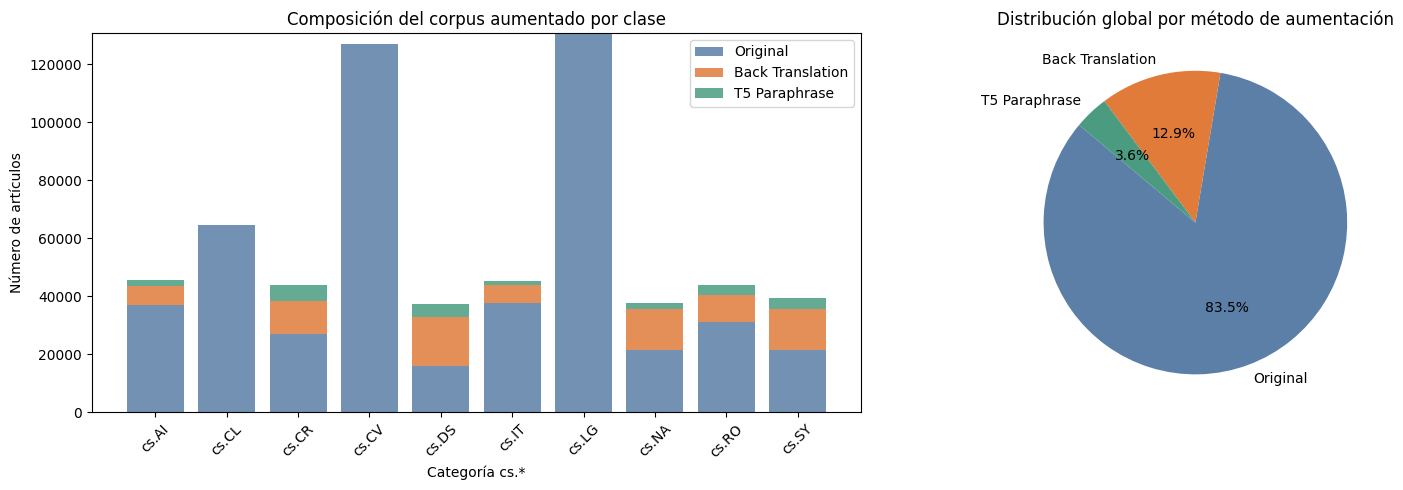

Figura guardada: corpus_aumentado_composicion.png


In [26]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

dist_final = df_aug.groupby(['cs_primary', 'aug_method']).size().unstack(fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

#  Barras apiladas: composición por clase 
colors = {'original': '#5b7fa6', 'back_translation': '#e07b39', 't5_paraphrase': '#4a9b7f'}
bottom = np.zeros(len(dist_final))
for method in ['original', 'back_translation', 't5_paraphrase']:
    if method in dist_final.columns:
        vals = dist_final[method].values
        axes[0].bar(dist_final.index, vals, bottom=bottom,
                    label=method.replace('_', ' ').title(),
                    color=colors[method], alpha=0.85)
        bottom += vals

axes[0].set_title('Composición del corpus aumentado por clase', fontsize=12)
axes[0].set_xlabel('Categoría cs.*')
axes[0].set_ylabel('Número de artículos')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

#  Pie: distribución global de métodos 
method_totals = df_aug['aug_method'].value_counts()
wedge_colors  = [colors.get(m, '#aaa') for m in method_totals.index]
axes[1].pie(
    method_totals.values,
    labels=[m.replace('_', ' ').title() for m in method_totals.index],
    colors=wedge_colors,
    autopct='%1.1f%%',
    startangle=140
)
axes[1].set_title('Distribución global por método de aumentación', fontsize=12)

plt.tight_layout()
plt.savefig('corpus_aumentado_composicion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: corpus_aumentado_composicion.png')

In [29]:
#  Tabla resumen final 
print('=' * 65)
print('RESUMEN FASE 2 — AUMENTACIÓN DE DATOS')
print('=' * 65)
print(f'Techo de balanceo: {AUG_CEILING:,} (estrategia: raiz de clase mayoritaria)')
print(f'Dataset entrada  : {OUTPUT_TRAIN}  ({len(df_orig):,} filas)')
print(f'Dataset salida   : {OUTPUT_FILE} ({len(df_aug):,} filas)')
print(f'Incremento total : +{len(df_aug)-len(df_orig):,} filas ({(len(df_aug)/len(df_orig)-1)*100:.1f}%)')
print()

clases_ordenadas = dist.sort_values().index

print(f"{'Clase':<10} {'Orig':>10} {'BT':>10} {'T5':>10} {'Total':>10}")
print("-" * 55)

for cls in clases_ordenadas:
    orig = dist[cls]
    
    bt_n = len(df_aug[(df_aug['cs_primary'] == cls) & (df_aug['aug_method'] == 'back_translation')]) if len(df_aug) > 0 else 0
    t5_n = len(df_aug[(df_aug['cs_primary'] == cls) & (df_aug['aug_method'] == 't5_paraphrase')]) if len(df_aug) > 0 else 0
    
    tot = orig + bt_n + t5_n
    
    print(f'{cls:<10} {orig:>10,} {bt_n:>10,} {t5_n:>10,} {tot:>10,}')

RESUMEN FASE 2 — AUMENTACIÓN DE DATOS
Techo de balanceo: 50,000 (estrategia: raiz de clase mayoritaria)
Dataset entrada  : C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_train_orig.parquet  (513,667 filas)
Dataset salida   : C:\Users\AaronMCC\Documents\arxiv_cs_dataset_exploration\dataset\arxiv_test_aug.parquet (615,354 filas)
Incremento total : +101,687 filas (19.8%)

Clase            Orig         BT         T5      Total
-------------------------------------------------------
cs.DS          15,922     17,030      4,395     37,347
cs.NA          21,420     14,290      1,852     37,562
cs.SY          21,530     14,231      3,560     39,321
cs.CR          26,922     11,533      5,455     43,910
cs.RO          30,964      9,517      3,430     43,911
cs.AI          37,040      6,479      2,166     45,685
cs.IT          37,587      6,203      1,597     45,387
cs.CL          64,532          0          0     64,532
cs.CV         126,937          0          0    126,93